In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
ruta = "https://raw.githubusercontent.com/jamc88/TSMA-II-26-O/refs/heads/main/Datos/panel_o3_2026.csv" 

panel = pd.read_csv(ruta,parse_dates=["timestamp", "fecha"])
panel

,timestamp,fecha,hora,estacion,o3,imputado,baja_disponibilidad
0,2026-01-01 01:00:00,2026-01-01,1,AJM,19.0,False,False
1,2026-01-01 02:00:00,2026-01-01,2,AJM,23.0,False,False
2,2026-01-01 03:00:00,2026-01-01,3,AJM,30.0,False,False
3,2026-01-01 04:00:00,2026-01-01,4,AJM,34.0,False,False
4,2026-01-01 05:00:00,2026-01-01,5,AJM,36.0,False,False
...,...,...,...,...,...,...,...
19819,2026-02-28 20:00:00,2026-02-28,20,VIF,28.0,False,False
19820,2026-02-28 21:00:00,2026-02-28,21,VIF,24.0,False,False
19821,2026-02-28 22:00:00,2026-02-28,22,VIF,18.0,False,False
19822,2026-02-28 23:00:00,2026-02-28,23,VIF,3.0,False,False


## Integración de una segunda fuente: temperatura

Hasta ahora nuestro panel contiene principalmente información de ozono:

$$
Y_{i,t}
=
\text{concentración de O}_3
\text{ en la estación }i
\text{ durante el tiempo }t.
$$

Ahora incorporaremos una segunda fuente de información: registros horarios de **temperatura**.

La nueva variable puede representarse como

$$
T_{i,t}
=
\text{temperatura registrada en la estación }i
\text{ durante el tiempo }t.
$$

Nuestro objetivo es construir un panel multivariado de la forma

$$
\boxed{
(i,t,Y_{i,t},T_{i,t})
}
$$

es decir,

$$
\boxed{
(\text{estación},
\text{tiempo},
\text{O}_3,
\text{temperatura})
}.
$$



### Un problema importante: las fuentes no necesariamente coinciden

Aunque ambas bases utilizan estaciones de monitoreo y registros horarios, debemos verificar que:

1. las estaciones tengan las mismas claves;
2. los calendarios sean compatibles;
3. las observaciones tengan la misma frecuencia temporal;
4. exista información para la misma combinación $(i,t)$.

Por tanto, antes de realizar la integración debemos encontrar la intersección

$$
\mathcal{I}_{O_3}
\cap
\mathcal{I}_{TMP},
$$

donde $\mathcal{I}_{O_3}$ es el conjunto de estaciones con ozono y
$\mathcal{I}_{TMP}$ el conjunto de estaciones con temperatura.

Posteriormente integraremos ambas fuentes utilizando como clave

$$
\boxed{(\text{estacion},\text{timestamp})}.
$$

Esto constituye un ejemplo real de integración de múltiples fuentes de datos.

In [3]:
url = "https://github.com/jamc88/TSMA-II-26-O/raw/refs/heads/main/Datos/2026TMP.xls"

tmp_raw = pd.read_excel(url, engine="xlrd")
tmp_raw

,FECHA,HORA,ACO,AJM,AJU,BJU,CHO,CUA,CUT,FAC,...,PED,SAC,SAG,SFE,TAH,TLA,UAX,UIZ,VIF,XAL
0,2026-01-01,1,8.1,9.7,-99,14.0,12.6,-99.0,10.1,-99.0,...,13.1,-99,14.4,-99,-99,-99,13.9,-99,12.7,-99
1,2026-01-01,2,6.8,8.6,-99,13.3,11.6,-99.0,8.7,-99.0,...,12.1,-99,13.6,-99,-99,-99,13.2,-99,11.8,-99
2,2026-01-01,3,5.9,8.0,-99,12.1,11.2,-99.0,7.5,-99.0,...,11.5,-99,13.0,-99,-99,-99,12.0,-99,9.8,-99
3,2026-01-01,4,5.1,7.9,-99,11.5,10.0,-99.0,6.9,-99.0,...,11.0,-99,11.6,-99,-99,-99,11.1,-99,9.7,-99
4,2026-01-01,5,4.4,7.5,-99,11.1,9.2,-99.0,6.4,-99.0,...,10.6,-99,11.3,-99,-99,-99,10.3,-99,8.6,-99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5083,2026-07-31,20,-99.0,-99.0,-99,18.4,15.8,14.9,-99.0,15.7,...,17.7,-99,-99.0,-99,-99,-99,17.0,-99,17.6,-99
5084,2026-07-31,21,-99.0,-99.0,-99,15.3,16.0,13.2,-99.0,15.7,...,14.7,-99,-99.0,-99,-99,-99,15.5,-99,16.6,-99
5085,2026-07-31,22,-99.0,-99.0,-99,15.3,15.9,12.7,-99.0,15.7,...,14.7,-99,-99.0,-99,-99,-99,15.6,-99,15.3,-99
5086,2026-07-31,23,-99.0,-99.0,-99,15.1,15.7,12.8,-99.0,15.3,...,14.8,-99,-99.0,-99,-99,-99,15.3,-99,15.0,-99


In [4]:
# Identificación de estaciones

estaciones_tmp = [
    col for col in tmp_raw.columns
    if col not in ["FECHA", "HORA"]
]

print("\nNúmero de estaciones con temperatura:")
print(len(estaciones_tmp))

# Preparación temporal
tmp = tmp_raw.copy()

# -99 representa información faltante
tmp[estaciones_tmp] = tmp[estaciones_tmp].replace(-99, np.nan)

tmp["FECHA"] = pd.to_datetime(tmp["FECHA"],errors="coerce")

# Se conserva la misma convención utilizada con O3:
tmp["timestamp"] = tmp["FECHA"] + pd.to_timedelta(tmp["HORA"], unit="h")

print("\nPeriodo disponible:")
print(tmp["timestamp"].min())
print(tmp["timestamp"].max())


Número de estaciones con temperatura:
28

Periodo disponible:
2026-01-01 01:00:00
2026-08-01 00:00:00


In [5]:
# Estaciones presentes en ambas fuentes

estaciones_o3 = sorted(
    panel["estacion"].unique()
)

estaciones_comunes = sorted(set(estaciones_o3).intersection(estaciones_tmp))

print("\nEstaciones del panel de O3:")
print(len(estaciones_o3))

print("\nEstaciones presentes también en temperatura:")
print(len(estaciones_comunes))

print(estaciones_comunes)

# Estaciones de O3 sin correspondencia en temperatura
sin_temperatura = sorted(set(estaciones_o3) - set(estaciones_tmp))

print("\nEstaciones de O3 sin columna de temperatura:")
print(sin_temperatura)


Estaciones del panel de O3:
14

Estaciones presentes también en temperatura:
12
['AJM', 'FAC', 'GAM', 'HGM', 'INN', 'MER', 'MGH', 'PED', 'TLA', 'UAX', 'UIZ', 'VIF']

Estaciones de O3 sin columna de temperatura:
['ATI', 'LLA']


## Cobertura de temperatura durante el periodo del panel de O$_3$

Las dos bases no tienen exactamente la misma extensión temporal.

El panel de ozono comprende el periodo

$$
\mathcal{T}_{O_3},
$$

mientras que la base de temperatura contiene información para un intervalo más amplio.

Para integrar ambas fuentes debemos restringir la temperatura al mismo periodo temporal:

$$
\mathcal{T}_{O_3}
\cap
\mathcal{T}_{TMP}.
$$

Además, que una estación exista en ambas bases no implica que tenga observaciones de temperatura disponibles durante todo el periodo.

Para cada estación común calcularemos

$$
C_i
=
\frac{
\text{observaciones de temperatura disponibles}
}{
\text{observaciones esperadas}
}
\times100.
$$

Como criterio práctico utilizaremos nuevamente

$$
\boxed{C_i\geq90\%}
$$

para seleccionar estaciones con información meteorológica suficientemente completa.

Este paso es importante porque integrar una variable con una gran cantidad de valores faltantes podría deteriorar el panel multivariado final.

In [6]:
# Periodo temporal del panel de O3

inicio_o3 = panel["timestamp"].min()
fin_o3 = panel["timestamp"].max()

print("Periodo del panel de O3:")
print(inicio_o3, "→", fin_o3)


# Temperatura restringida al mismo periodo

tmp_periodo = tmp.loc[tmp["timestamp"].between(inicio_o3,fin_o3)].copy()

print("\nNúmero de registros horarios de temperatura:")
print(len(tmp_periodo))

print("\nNúmero de tiempos distintos:")
print(tmp_periodo["timestamp"].nunique())


# Cobertura por estación común

n_esperadas = tmp_periodo["timestamp"].nunique()

cobertura_tmp = pd.DataFrame({
    "n_esperadas": n_esperadas,
    "n_disponibles":tmp_periodo[estaciones_comunes].notna().sum()
})

cobertura_tmp["n_faltantes"] =  cobertura_tmp["n_esperadas"] - cobertura_tmp["n_disponibles"]

cobertura_tmp["cobertura_pct"] =  100 * cobertura_tmp["n_disponibles"] / cobertura_tmp["n_esperadas"]

cobertura_tmp = cobertura_tmp.sort_values("cobertura_pct", ascending=False)


print("\nCobertura de temperatura:")
cobertura_tmp.round(2)

Periodo del panel de O3:
2026-01-01 01:00:00 → 2026-03-01 00:00:00

Número de registros horarios de temperatura:
1416

Número de tiempos distintos:
1416

Cobertura de temperatura:


,n_esperadas,n_disponibles,n_faltantes,cobertura_pct
MGH,1416,1416,0,100.00
UAX,1416,1416,0,100.00
MER,1416,1413,3,99.79
PED,1416,1403,13,99.08
AJM,1416,1248,168,88.14
VIF,1416,1140,276,80.51
GAM,1416,23,1393,1.62
FAC,1416,0,1416,0.00
HGM,1416,0,1416,0.00
INN,1416,0,1416,0.00


In [7]:
# Selección con cobertura >= 90 %

estaciones_tmp_validas = (
    cobertura_tmp.loc[cobertura_tmp["cobertura_pct"] >= 90].index.tolist()
)

print("\nEstaciones con cobertura de temperatura >= 90 %:")
print(len(estaciones_tmp_validas))
print(estaciones_tmp_validas)


Estaciones con cobertura de temperatura >= 90 %:
4
['MGH', 'UAX', 'MER', 'PED']


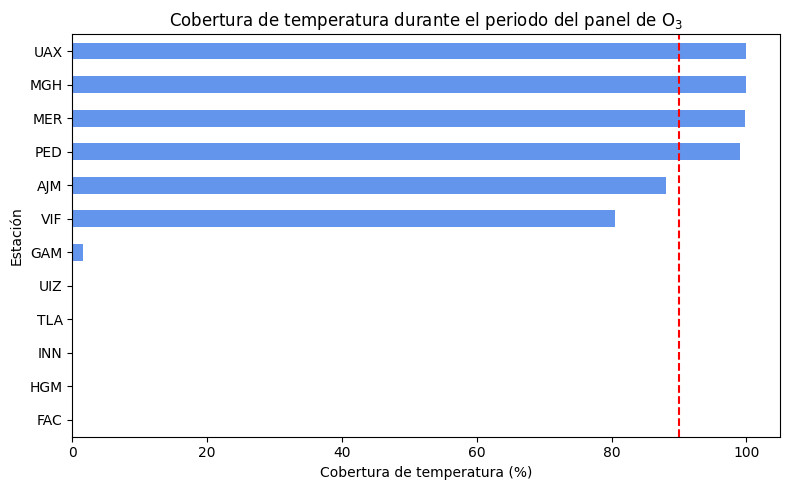

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

cobertura_tmp["cobertura_pct"].sort_values().plot(kind="barh", ax=ax, color = 'cornflowerblue')

ax.axvline(90,linestyle="--",linewidth=1.5, color='red')
ax.set_xlabel("Cobertura de temperatura (%)")
ax.set_ylabel("Estación")
ax.set_title("Cobertura de temperatura durante el periodo del panel de O$_3$")

plt.tight_layout()
plt.show()

## Integración del panel de O$_3$ con temperatura

Después del diagnóstico de cobertura conservaremos las estaciones con

$$
C_i\geq90\%.
$$

Las estaciones seleccionadas son:

$$
\boxed{
\text{MGH},\;
\text{UAX},\;
\text{MER},\;
\text{PED}
}
$$

Para estas estaciones construiremos una segunda tabla en formato largo:

```text
timestamp | estacion | temperatura

In [9]:
# 1. Temperatura en formato largo

tmp_largo = (
    tmp_periodo[["timestamp"] + estaciones_tmp_validas]
    .melt(
        id_vars="timestamp",
        var_name="estacion",
        value_name="temperatura"
    )
    .sort_values(["estacion", "timestamp"]).reset_index(drop=True)
)

print("Temperatura en formato largo:")
print("Dimensiones:", tmp_largo.shape)

tmp_largo

Temperatura en formato largo:
Dimensiones: (5664, 3)


,timestamp,estacion,temperatura
0,2026-01-01 01:00:00,MER,15.0
1,2026-01-01 02:00:00,MER,14.1
2,2026-01-01 03:00:00,MER,12.5
3,2026-01-01 04:00:00,MER,11.9
4,2026-01-01 05:00:00,MER,11.1
...,...,...,...
5659,2026-02-28 20:00:00,UAX,23.0
5660,2026-02-28 21:00:00,UAX,21.6
5661,2026-02-28 22:00:00,UAX,20.4
5662,2026-02-28 23:00:00,UAX,19.7


In [10]:
# 2. Subconjunto de O3 para las mismas estaciones

panel_o3_tmp = panel.loc[panel["estacion"].isin(estaciones_tmp_validas)].copy()


print("\nPanel de O3 para las estaciones seleccionadas:")
print("Dimensiones:", panel_o3_tmp.shape)


Panel de O3 para las estaciones seleccionadas:
Dimensiones: (5664, 7)


In [11]:
# 3. Integración O3 + temperatura

panel_o3_temperatura = (
    panel_o3_tmp
    .merge(tmp_largo, on=["estacion","timestamp"], how="left", validate="one_to_one")
    .sort_values(["estacion", "timestamp"]).reset_index(drop=True)
)
panel_o3_temperatura

,timestamp,fecha,hora,estacion,o3,imputado,baja_disponibilidad,temperatura
0,2026-01-01 01:00:00,2026-01-01,1,MER,7.0,False,False,15.0
1,2026-01-01 02:00:00,2026-01-01,2,MER,3.0,False,False,14.1
2,2026-01-01 03:00:00,2026-01-01,3,MER,3.0,False,False,12.5
3,2026-01-01 04:00:00,2026-01-01,4,MER,3.0,False,False,11.9
4,2026-01-01 05:00:00,2026-01-01,5,MER,4.0,False,False,11.1
...,...,...,...,...,...,...,...,...
5659,2026-02-28 20:00:00,2026-02-28,20,UAX,42.0,False,False,23.0
5660,2026-02-28 21:00:00,2026-02-28,21,UAX,28.0,False,False,21.6
5661,2026-02-28 22:00:00,2026-02-28,22,UAX,19.0,False,False,20.4
5662,2026-02-28 23:00:00,2026-02-28,23,UAX,5.0,False,False,19.7


In [12]:
# 5. Verificaciones

print("\nNúmero de estaciones:")
print(panel_o3_temperatura["estacion"].nunique())

print("\nNúmero de instantes:")
print(panel_o3_temperatura["timestamp"].nunique())

print("\nNúmero esperado de observaciones:")
print(len(estaciones_tmp_validas) * 1416)

print("\nDuplicados estación-tiempo:")
print(panel_o3_temperatura.duplicated(["estacion", "timestamp"]).sum())


Número de estaciones:
4

Número de instantes:
1416

Número esperado de observaciones:
5664

Duplicados estación-tiempo:
0


In [13]:
# 6. Valores faltantes de temperatura

faltantes_tmp_final = (
    panel_o3_temperatura
    .groupby("estacion")["temperatura"]
    .agg(n_observaciones="size", n_disponibles="count")
)

faltantes_tmp_final["n_faltantes"] = (
    faltantes_tmp_final["n_observaciones"]
    - faltantes_tmp_final["n_disponibles"]
)

display(faltantes_tmp_final)

print("\nTotal de temperaturas faltantes:")
print( panel_o3_temperatura["temperatura"].isna().sum())

,n_observaciones,n_disponibles,n_faltantes
estacion,,,
MER,1416,1413,3
MGH,1416,1416,0
PED,1416,1403,13
UAX,1416,1416,0



Total de temperaturas faltantes:
16


## Imputación de los valores faltantes de temperatura

Después de integrar ambas fuentes permanecen únicamente $16$ valores faltantes de temperatura:

- $3$ en `MER`;
- $13$ en `PED`.

Como la temperatura es una variable temporal continua y los faltantes representan una proporción muy pequeña del panel, utilizaremos interpolación temporal dentro de cada estación.

Para una estación $i$, si la temperatura falta en un instante $t$ situado entre dos observaciones conocidas, aproximaremos su valor utilizando las observaciones temporales vecinas.

El procedimiento se aplicará **por estación**, evitando mezclar información entre estaciones distintas.

Además, conservaremos una variable indicadora

$$
I_{i,t}^{TMP}
=
\begin{cases}
1, & \text{si la temperatura fue imputada},\\
0, & \text{en otro caso}.
\end{cases}
$$

Esto mantiene la trazabilidad del preprocesamiento.

In [14]:
# temperaturas originalmente faltantes

panel_o3_temperatura["temperatura_imputada"] = panel_o3_temperatura["temperatura"].isna()

# Interpolación temporal dentro de cada estación

for estacion in estaciones_tmp_validas:

    mascara = (panel_o3_temperatura["estacion"] == estacion)

    serie_tmp = (
        panel_o3_temperatura
        .loc[mascara,["timestamp", "temperatura"]]
        .set_index("timestamp")
        .sort_index()
    )

    serie_tmp["temperatura"] = serie_tmp["temperatura"].interpolate(method="time", limit_direction="both")

    panel_o3_temperatura.loc[mascara,"temperatura"] = serie_tmp["temperatura"].to_numpy()


# Verificaciones
print("Temperaturas faltantes después de interpolar:")
print(panel_o3_temperatura["temperatura"].isna().sum())
print("\nNúmero de temperaturas imputadas:")
print(panel_o3_temperatura["temperatura_imputada"].sum())

Temperaturas faltantes después de interpolar:
0

Número de temperaturas imputadas:
16


In [15]:
# Mostrar observaciones imputadas

panel_o3_temperatura.loc[panel_o3_temperatura["temperatura_imputada"]]

,timestamp,fecha,hora,estacion,o3,imputado,baja_disponibilidad,temperatura,temperatura_imputada
32,2026-01-02 09:00:00,2026-01-02,9,MER,13.25,True,False,11.750000,True
33,2026-01-02 10:00:00,2026-01-02,10,MER,22.50,True,False,13.800000,True
34,2026-01-02 11:00:00,2026-01-02,11,MER,31.75,True,False,15.850000,True
3659,2026-02-04 12:00:00,2026-02-04,12,PED,53.00,False,False,15.871429,True
3660,2026-02-04 13:00:00,2026-02-04,13,PED,75.00,False,False,15.542857,True
3661,2026-02-04 14:00:00,2026-02-04,14,PED,92.00,False,False,15.214286,True
3662,2026-02-04 15:00:00,2026-02-04,15,PED,103.00,False,False,14.885714,True
3663,2026-02-04 16:00:00,2026-02-04,16,PED,105.00,False,False,14.557143,True
3664,2026-02-04 17:00:00,2026-02-04,17,PED,106.00,False,False,14.228571,True
3665,2026-02-04 18:00:00,2026-02-04,18,PED,74.00,False,False,13.900000,True


## Relación entre temperatura y ozono

Ahora disponemos de dos variables observadas para cada combinación estación--tiempo:

$$
Y_{i,t}=\text{O}_3,
$$

y

$$
T_{i,t}=\text{temperatura}.
$$

Esto nos permite estudiar una relación multivariada real.

Para cada estación calcularemos la correlación de Pearson entre temperatura y ozono:

$$
r_i
=
\operatorname{Corr}
\left(
T_{i,t},
Y_{i,t}
\right).
$$

En este análisis utilizaremos primero únicamente las observaciones cuya temperatura fue medida originalmente, es decir,

$$
\texttt{temperatura\_imputada}=\texttt{False}.
$$

Esto evita que los valores obtenidos mediante interpolación influyan artificialmente en la asociación.

Posteriormente construiremos diagramas de dispersión para observar directamente la relación entre ambas variables.

Una correlación positiva indicaría que, durante el periodo analizado, valores mayores de temperatura tienden a coincidir con mayores concentraciones de O$_3$.

Sin embargo,

$$
\boxed{\text{correlación}\neq\text{causalidad}}
$$

y la relación observada puede depender también de la hora del día, radiación solar, condiciones meteorológicas y otros factores.

In [16]:
# Observaciones con temperatura originalmente disponible

datos_observados = panel_o3_temperatura.loc[~panel_o3_temperatura["temperatura_imputada"]].copy()

# Correlación O3 - temperatura (por estación)

correlacion_tmp_o3 = (
    datos_observados
    .groupby("estacion")
    .apply(lambda x: x["o3"].corr(x["temperatura"], method="spearman"), include_groups=False)
    .rename("correlacion_o3_temperatura")
    .sort_values(ascending=False)
    .to_frame()
)

print("Correlación entre O3 y temperatura por estación:")
correlacion_tmp_o3.round(3)

Correlación entre O3 y temperatura por estación:


,correlacion_o3_temperatura
estacion,
UAX,0.860
PED,0.793
MER,0.760
MGH,0.741


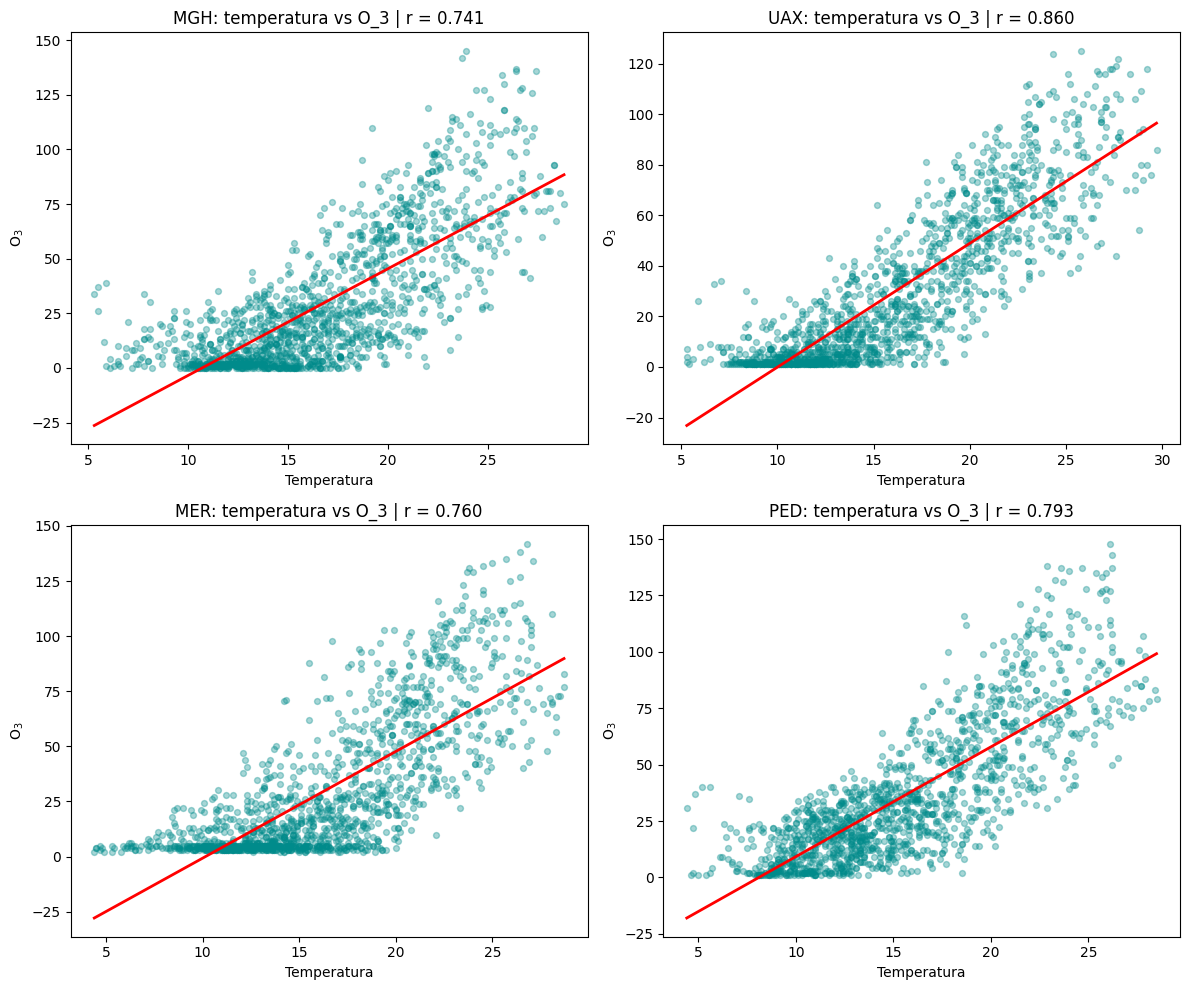

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()  # Aplanar la matriz 2x2 para recorrerla con un índice lineal

for i, estacion in enumerate(estaciones_tmp_validas):
    ax = axes[i]  
    
    datos_estacion = datos_observados.loc[
        datos_observados["estacion"] == estacion
    ]

    x = datos_estacion["temperatura"]
    y = datos_estacion["o3"]

    r = x.corr(y, method='spearman')

    # Recta de referencia
    pendiente, intercepto = np.polyfit(x, y, 1)

    x_linea = np.linspace(x.min(), x.max(), 100)
    y_linea = pendiente * x_linea + intercepto

    ax.scatter(x, y, alpha=0.35, s=18, color='darkcyan')
    ax.plot(x_linea, y_linea, linewidth=2, color='red')
    ax.set_xlabel("Temperatura")
    ax.set_ylabel("O$_3$")
    ax.set_title(f"{estacion}: temperatura vs O_3 | r = {r:.3f}")

plt.tight_layout()
plt.show()

In [18]:
panel_o3_temperatura

,timestamp,fecha,hora,estacion,o3,imputado,baja_disponibilidad,temperatura,temperatura_imputada
0,2026-01-01 01:00:00,2026-01-01,1,MER,7.0,False,False,15.0,False
1,2026-01-01 02:00:00,2026-01-01,2,MER,3.0,False,False,14.1,False
2,2026-01-01 03:00:00,2026-01-01,3,MER,3.0,False,False,12.5,False
3,2026-01-01 04:00:00,2026-01-01,4,MER,3.0,False,False,11.9,False
4,2026-01-01 05:00:00,2026-01-01,5,MER,4.0,False,False,11.1,False
...,...,...,...,...,...,...,...,...,...
5659,2026-02-28 20:00:00,2026-02-28,20,UAX,42.0,False,False,23.0,False
5660,2026-02-28 21:00:00,2026-02-28,21,UAX,28.0,False,False,21.6,False
5661,2026-02-28 22:00:00,2026-02-28,22,UAX,19.0,False,False,20.4,False
5662,2026-02-28 23:00:00,2026-02-28,23,UAX,5.0,False,False,19.7,False


In [19]:
panel_ancho = panel_o3_temperatura.pivot(index="timestamp", 
                                         columns="estacion", 
                                         values=["o3","temperatura"]).sort_index()
panel_ancho

o3                   temperatura                  
estacion              MER   MGH   PED   UAX         MER   MGH   PED   UAX
timestamp                                                                
2026-01-01 01:00:00   7.0  18.0   4.0  23.0        15.0  14.7  13.1  13.9
2026-01-01 02:00:00   3.0  17.0  12.0  11.0        14.1  13.9  12.1  13.2
2026-01-01 03:00:00   3.0   8.0  15.0   1.0        12.5  12.9  11.5  12.0
2026-01-01 04:00:00   3.0   3.0  18.0   2.0        11.9  12.4  11.0  11.1
2026-01-01 05:00:00   4.0   2.0  20.0   2.0        11.1  12.1  10.6  10.3
...                   ...   ...   ...   ...         ...   ...   ...   ...
2026-02-28 20:00:00  31.0  32.0  39.0  42.0        22.2  22.7  21.9  23.0
2026-02-28 21:00:00  28.0  30.0  34.0  28.0        20.6  21.1  20.3  21.6
2026-02-28 22:00:00  21.0  21.0  27.0  19.0        19.4  19.8  19.2  20.4
2026-02-28 23:00:00   9.0  11.0   8.0   5.0        18.8  19.0  17.4  19.7
2026-03-01 00:00:00   3.0  16.0  19.0   1.0        18.0  17.9  16.3  17.6

[1416 rows x 8 columns]

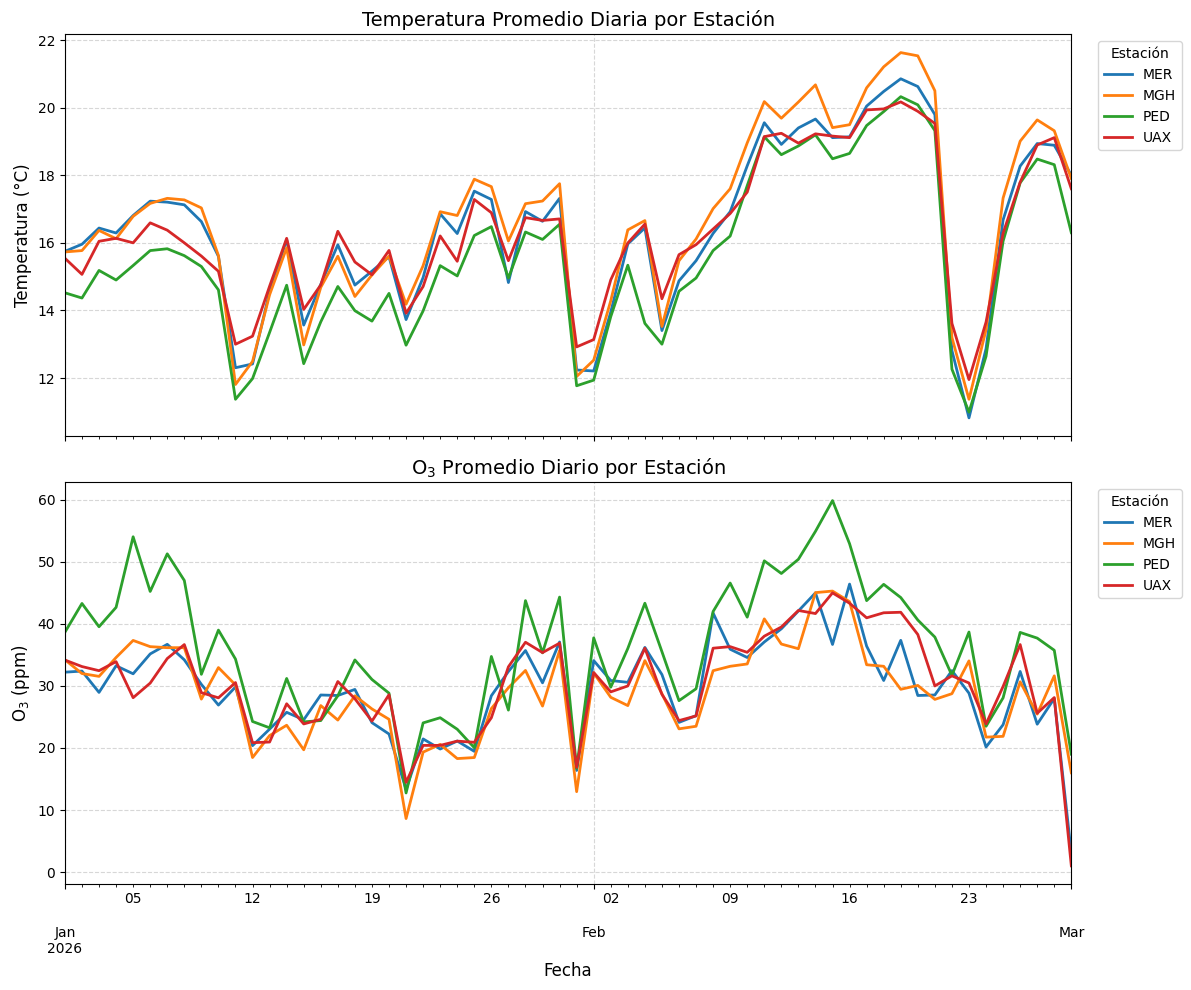

In [20]:
temp_diaria = panel_ancho["temperatura"].resample('D').mean()
o3_diario = panel_ancho["o3"].resample('D').mean()

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

temp_diaria.plot(ax=axes[0], linewidth=2)
axes[0].set_title("Temperatura Promedio Diaria por Estación", fontsize=14)
axes[0].set_ylabel("Temperatura (°C)", fontsize=12)
axes[0].legend(title="Estación", bbox_to_anchor=(1.02, 1), loc='upper left')
axes[0].grid(True, linestyle='--', alpha=0.5)

o3_diario.plot(ax=axes[1], linewidth=2)
axes[1].set_title("O$_3$ Promedio Diario por Estación", fontsize=14)
axes[1].set_xlabel("Fecha", fontsize=12)
axes[1].set_ylabel("O$_3$ (ppm)", fontsize=12)
axes[1].legend(title="Estación", bbox_to_anchor=(1.02, 1), loc='upper left')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## Panel multivariado final: O$_3$ y temperatura

La integración de las dos fuentes permitió construir un panel multivariado con la estructura

$$
(i,t,Y_{i,t},T_{i,t}),
$$

donde:

- $i$ representa la estación;
- $t$ representa la hora;
- $Y_{i,t}$ es la concentración de O$_3$;
- $T_{i,t}$ es la temperatura.

Después de revisar la cobertura de ambas fuentes se conservaron cuatro estaciones:

$$
\boxed{
\text{MER},\;
\text{MGH},\;
\text{PED},\;
\text{UAX}
}
$$

para un total de

$$
4\times1416=5664
$$

combinaciones estación--tiempo.

La integración mostró además que trabajar con múltiples fuentes requiere verificar:

$$
\boxed{
\text{claves}
\rightarrow
\text{calendarios}
\rightarrow
\text{cobertura}
\rightarrow
\text{faltantes}
\rightarrow
\text{integración}
}
$$

La asociación entre temperatura y ozono resultó positiva en las cuatro estaciones, con correlaciones aproximadamente entre $0.76$ y $0.86$.

Esto significa que, durante el periodo analizado, temperaturas mayores tienden a coincidir con concentraciones mayores de O$_3$.

Sin embargo, la dispersión observada muestra que la temperatura por sí sola no determina la concentración de ozono.

El panel construido queda preparado para análisis posteriores, por ejemplo:

- rezagos;
- diferencias;
- tasas de cambio;
- ventanas móviles;
- modelos predictivos;
- análisis de anomalías.

Conservaremos además las variables indicadoras de imputación para mantener la trazabilidad del preprocesamiento.

In [21]:
# Verificaciones finales

print("\nDimensiones:")
print(panel_o3_temperatura.shape)

print("\nEstaciones:")
print(panel_o3_temperatura["estacion"].nunique())

print("\nInstantes temporales:")
print(panel_o3_temperatura["timestamp"].nunique())

print("\nValores faltantes en O3:")
print(panel_o3_temperatura["o3"].isna().sum())

print("\nValores faltantes en temperatura:")
print(panel_o3_temperatura["temperatura"].isna().sum())

print("\nDuplicados estación-tiempo:")
print(panel_o3_temperatura.duplicated(["estacion", "timestamp"]).sum())


Dimensiones:
(5664, 9)

Estaciones:
4

Instantes temporales:
1416

Valores faltantes en O3:
0

Valores faltantes en temperatura:
0

Duplicados estación-tiempo:
0


In [22]:
# Guardado
panel_o3_temperatura.to_csv("panel_o3_temperatura_2026.csv",index=False)